# Logistic Regression - Churn prediction of Bank Customers

A churn prediction machine learning (ML) project aims to develop a model that can identify customers likely to stop using a company's service based on historical data. This allows businesses to take proactive measures to retain customers and reduce revenue loss

## Key Concepts

### a. Objective:  
To predict a binary outcome: whether a customer will "churn" (leave) or "not churn" (stay).  

### b. Data Sources: 
Projects typically use datasets containing customer demographics (age, location, gender), account information (tenure, contract type, payment method), and service details/usage behavior (internet service, tech support tickets, monthly charges).  

### c. Methodology:  
The process generally follows standard ML steps, including data preprocessing, exploratory data analysis (EDA), feature engineering, model selection, hyperparameter tuning, and evaluation.  

### d. Algorithms Used:  
Common classification algorithms include Logistic Regression, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Gradient Boosting, and Neural Networks. Ensemble and deep learning models have shown promising results. 

## Typical Project Workflow:
A standard churn prediction project follows a structured approach:  

### 1. Data Acquisition and Preprocessing:  
a. Load the dataset (e.g., from Kaggle or a database).  
b. Handle missing values and outliers.  
c. Convert categorical features (e.g., 'Yes'/'No') into numerical formats using techniques like one-hot encoding or label encoding.  
d. Split the data into training and testing sets (commonly a 70:30 ratio).  

### 2. Exploratory Data Analysis (EDA):
a. Analyze the relationships between different variables and the target variable ('Churn').  
b. Identify key factors and patterns that drive churn, such as contract type (month-to-month contracts often have higher churn) or initial customer experience issues.  
c. Visualize data distribution using libraries like Matplotlib or Seaborn.  

### 3. Model Building and Training:
a. Train several ML models (e.g., Logistic Regression, Random Forest, Gradient Boosting) on the training data.  

### 4. Model Evaluation and Tuning:
a. Evaluate model performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score, AUROC) on the test set.  

### 5. Conclusion and Recommendations:  
a. Select the best performing model.  
b. Translate model insights into actionable business strategies, such as improving onboarding processes, offering incentives for long-term contracts, or addressing specific technical issues.  

### 6. Future steps might involve deploying the model as a web application for real-time use. 

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


### Load Dataset

In [174]:
df = pd.read_csv('Dataset/archive/churn.csv')

In [175]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [177]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [178]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

This Dataset have following columns:  

1. RowNumber  --> No effect on output  
2. CustomerId --> No effect on output  
3. Surname    --> Customer name  
4. CreditScore --> Total credit_score of customer in the bank  [Effect on churn]   
5. Geography   --> Location of customer  [Effect on churn]  
6. Gender      --> Customer's Gender [For exploration of the effect of Gender on churn]  
7. Age         --> Customers age  [Effect on churn]  
8. Tenure      --> No. of years the customer is the client of bank  [Effect on churn]  
9. Balance     --> Customers balance  [Effect on churn]  
10. NumOfProducts --> No. of products customer have purchased through the bank  [Effect on churn]  
11. HasCrCard     --> Customer have credit card - Boolean values 0/1  [Effect on churn]  
12. IsActiveMember  --> Boolean values 0/1  [Effect on churn]  
13. EstimatedSalary --> Estimated salary of customer  [Effect on churn]  
14. Exited          --> whether or not the customer left the bank  

## Exploratory Data Analysis (EDA)

In [179]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [180]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There is no Null and NAN values in the dataset. So, the dataset is cleaned 

#### Analysing the effect of features on Churn

##### 1. How many customers have left/not left the Bank 

In [181]:
results = df['Exited'].value_counts()

In [182]:
results

Exited
0    7963
1    2037
Name: count, dtype: int64

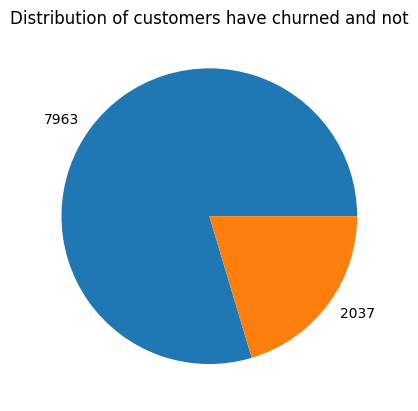

In [183]:
plt.pie(results, labels=results)
plt.title('Distribution of customers have churned and not')
plt.show()

##### 2. Analyzing Numerical features

In [184]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

##### 3. Analyzing Categorical features

In [185]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

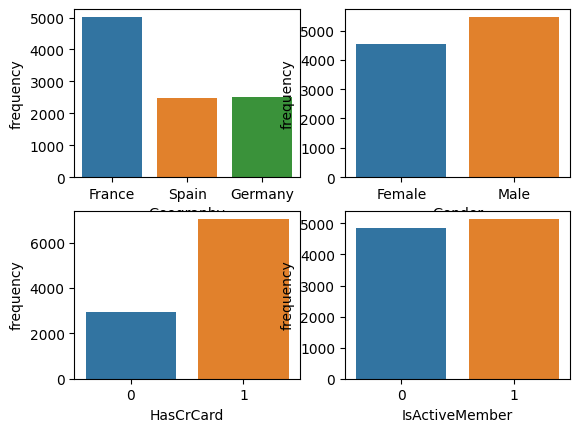

In [186]:
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for i, column in enumerate(categorical_features):
    plt.subplot(2,2, i+1)
    sns.countplot(x=df[column])
    #plt.title(column)
    plt.xlabel(column)
    plt.ylabel('frequency')

plt.show()

##### 3. Analyzing Independent features based on output (Exited) column

In [187]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

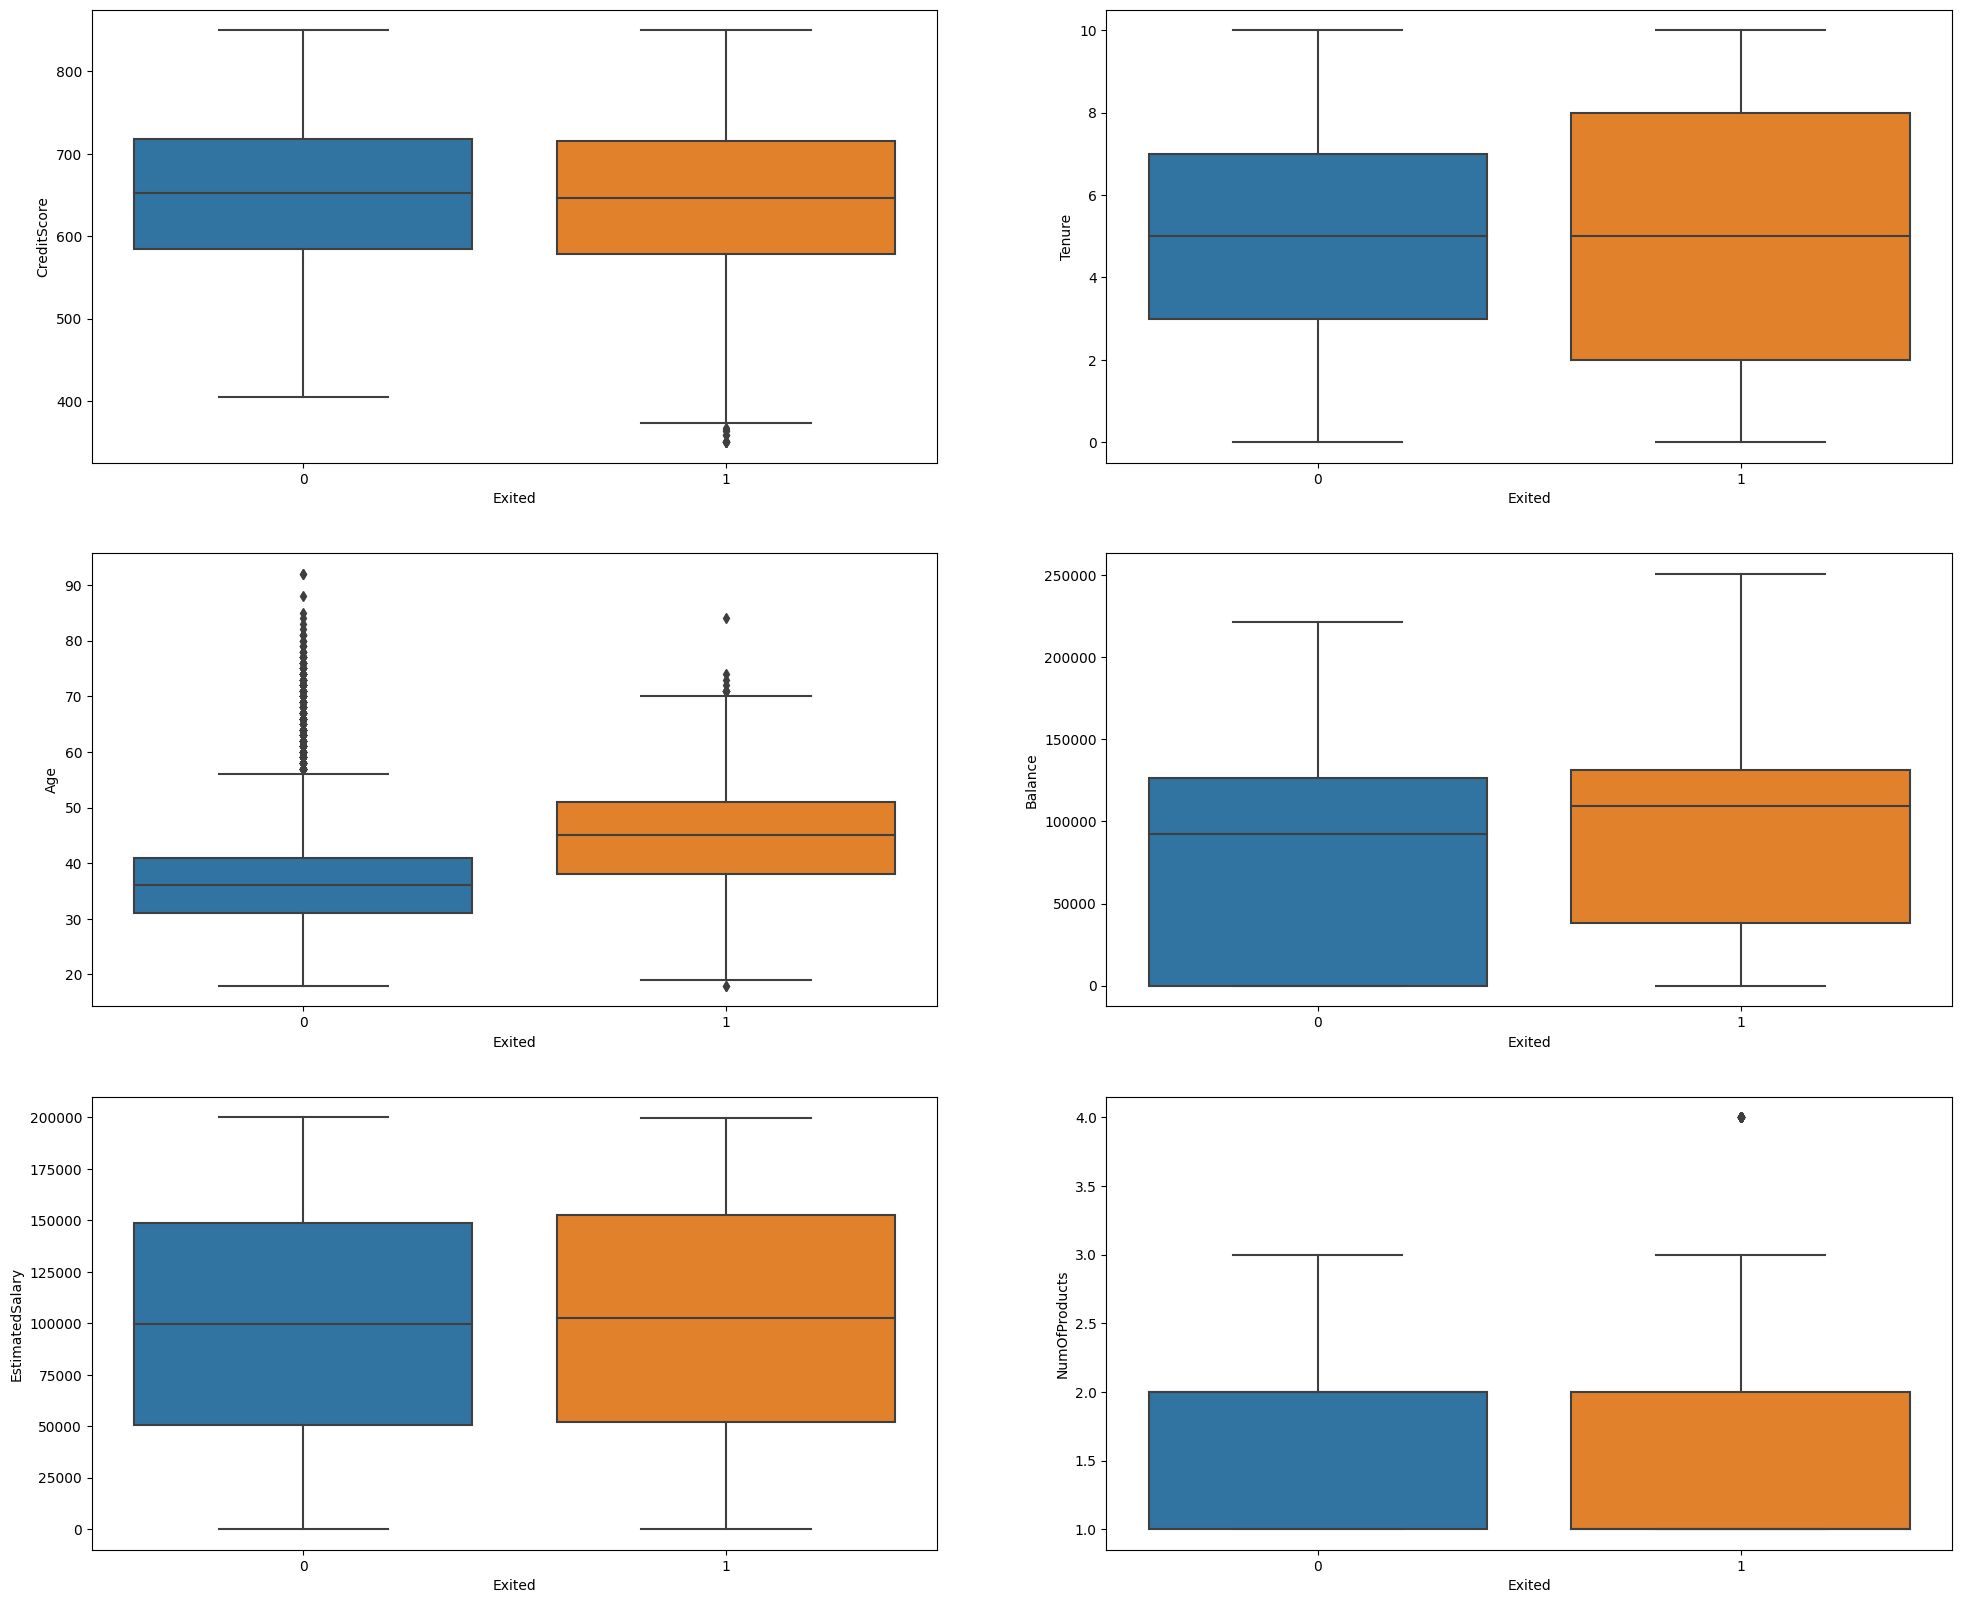

In [188]:
fig, ax = plt.subplots(3,2, figsize=(24,20))

# CreditScore
sns.boxplot(data=df, x='Exited', y='CreditScore', ax=ax[0,0])
# Tenure
sns.boxplot(data=df, x='Exited', y='Tenure', ax=ax[0,1])
# Age
sns.boxplot(data=df, x='Exited', y='Age', ax=ax[1,0])
# Balance 
sns.boxplot(data=df, x='Exited', y='Balance', ax=ax[1,1])
# ExtimatedSalary
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', ax=ax[2,0])
# No. of products
sns.boxplot(data=df, x='Exited', y='NumOfProducts', ax=ax[2,1])

plt.show()

##### 4. 

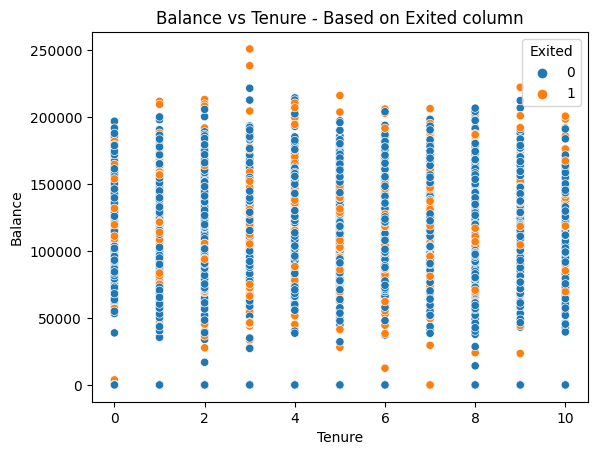

In [189]:
sns.scatterplot(data=df, x='Tenure', y='Balance', hue='Exited')
plt.title('Balance vs Tenure - Based on Exited column')
plt.show()

##### 5. Feature Engineering

In [190]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [191]:
df['CreditUtilization'] = df['Balance']/df['CreditScore']
# Interaction Score
df['InteractionScore'] = df['NumOfProducts'] + df['HasCrCard'] + df['IsActiveMember']
# Balance to Salary Ratio
df['BalanceToSalary'] = df['Balance']/df['EstimatedSalary']

##### 6. Visualizing Heatmap

In [192]:
df_new = df.drop(['Surname', 'RowNumber', 'CustomerId', 'Geography', 'Gender'], axis=1)

In [193]:
df_new

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,502,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,516,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,772,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


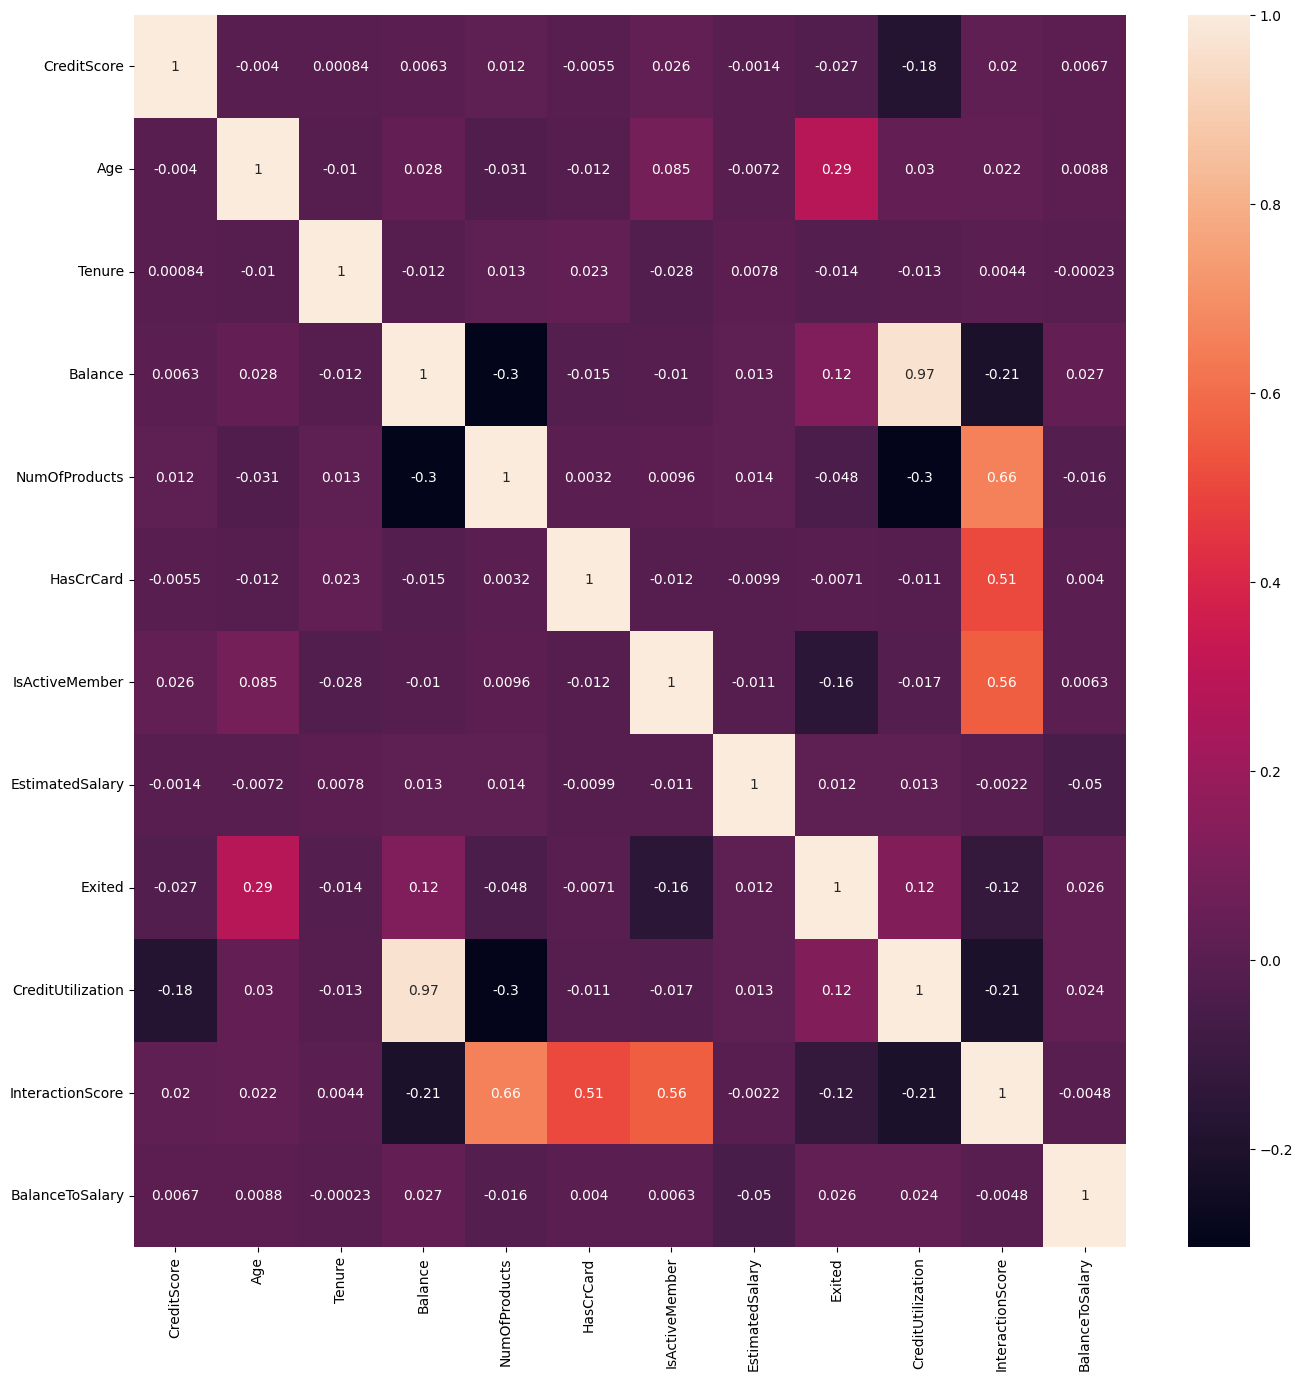

In [194]:
plt.figure(figsize=(16,16))
sns.heatmap(df_new.corr(), annot=True)

plt.show()

In [195]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


In [196]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

### One-Hot Encoding and Label Encoding

Applying label Encoding to gender column


In [197]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])  # Male =1 , Female=0

In [198]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


In [199]:
df['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [200]:
# Step 4: One-Hot Encode Geography
ohe = OneHotEncoder(sparse_output=False) 

geo_encoded = ohe.fit_transform(df[['Geography']])

In [202]:
geo_encoded

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [205]:
ohe.get_feature_names_out()

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [206]:
geo_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out())

In [207]:
df = df.drop('Geography', axis=1)

In [208]:
# Combine encoded Geography with the rest of the dataset
df = pd.concat([df, geo_df], axis=1)

In [209]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230,0.0,1.0,0.0


##### 7. Seperate dependent and Independent features

In [210]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'CreditUtilization', 'InteractionScore', 'BalanceToSalary',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [211]:
X = df.drop(['Exited'], axis=1)
Y = df['Exited']

In [212]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [213]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [226]:
Logistic_regression = LogisticRegression(max_iter=10000,  class_weight='balanced')

In [227]:
X_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,CreditUtilization,InteractionScore,BalanceToSalary,Geography_France,Geography_Germany,Geography_Spain
9069,619,0,32,4,175406.13,2,1,1,172792.43,283.370162,4,1.015126,0.0,0.0,1.0
2603,643,0,34,7,160426.07,1,0,1,188533.11,249.496221,2,0.850917,0.0,1.0,0.0
7738,561,1,33,6,0.00,2,0,0,173680.39,0.000000,2,0.000000,1.0,0.0,0.0
1579,618,1,41,8,37702.79,1,1,1,195775.48,61.007751,3,0.192582,0.0,1.0,0.0
5058,714,1,37,9,148466.93,2,0,1,151280.96,207.936877,3,0.981399,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,1,54,8,69712.74,1,1,1,69381.05,90.771797,3,1.004781,1.0,0.0,0.0
5191,682,0,58,1,0.00,1,1,1,706.50,0.000000,3,0.000000,1.0,0.0,0.0
5390,735,0,38,1,0.00,3,0,0,92220.12,0.000000,3,0.000000,1.0,0.0,0.0
860,667,1,43,8,190227.46,1,1,0,97508.04,285.198591,2,1.950890,1.0,0.0,0.0


In [228]:
Y_train

9069    1
2603    0
7738    0
1579    0
5058    0
       ..
5734    0
5191    0
5390    1
860     1
7270    0
Name: Exited, Length: 7000, dtype: int64

In [229]:
Logistic_regression.fit(X_train, Y_train)

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=10000)

In [230]:
y_pred = Logistic_regression.predict(X_test)

In [231]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.69      0.79      2416
           1       0.36      0.71      0.48       584

    accuracy                           0.70      3000
   macro avg       0.63      0.70      0.63      3000
weighted avg       0.80      0.70      0.73      3000



In [233]:
print(confusion_matrix(Y_test, y_pred))

[[1678  738]
 [ 171  413]]


<Axes: >

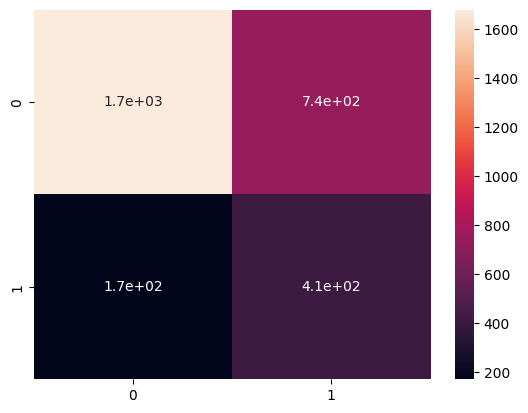

In [234]:
sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True)

In [235]:
print(accuracy_score(Y_test, y_pred))

0.697


In [236]:
print(precision_score(Y_test, y_pred))

0.35881841876629017


In [237]:
print(recall_score(Y_test, y_pred))

0.7071917808219178


In [238]:
print(f1_score(Y_test, y_pred))

0.4760806916426513


#### Save model, and Encoders and scalard for creating app

In [239]:
import joblib

In [244]:
joblib.dump(label_encoder, 'churn_label_encoder.pkl')
joblib.dump(ohe, 'churn_One_hot_encoder.pkl')
joblib.dump(scaler, 'churn_scala.pkl')
joblib.dump(Logistic_regression, 'churn_logistic_regression_model.pkl')

['churn_logistic_regression_model.pkl']